# Resumen ejecutado · INF-8239 U02 · Visión computacional (Fashion-MNIST)

Este notebook reutiliza el código de `src/inf8239_u02_cv` para auditar el dataset, cargar el modelo
CNN entrenado (`models/best_cnn.keras`) y verificar de forma independiente las métricas reportadas en
`reports/cv_metrics.json`. Es evidencia ejecutada para el Ejercicio 04, no una copia de resultados.

## 1. Entorno y versiones

In [1]:
import json
import platform
import sys
from pathlib import Path

import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, f1_score

ROOT = Path.cwd().parent if (Path.cwd() / "notebooks").exists() is False else Path.cwd()
ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from inf8239_u02_cv.data import normalize_images, validate_images  # noqa: E402

print("Python:", platform.python_version())
print("TensorFlow:", tf.__version__)
print("Raiz del proyecto:", ROOT)

Python: 3.12.15
TensorFlow: 2.21.0
Raiz del proyecto: C:\Users\alexb\Desktop\Maestría\Ciencia_de_Datos_II\Unidad 2\INF8239_U02_CV_Proyecto_Base


## 2. Auditoría y partición reproducible

Se repite exactamente la misma partición usada en `scripts/train_cv.py`: las últimas 6,000 filas del
set de entrenamiento original se separan como validación (54,000 / 6,000), sin tocar el set de prueba.

In [2]:
(x_train_all, y_train_all), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

x_train_all = normalize_images(x_train_all)
x_test = normalize_images(x_test)

x_train, y_train = x_train_all[:-6000], y_train_all[:-6000]
x_valid, y_valid = x_train_all[-6000:], y_train_all[-6000:]

validate_images(x_train, y_train)
validate_images(x_valid, y_valid)
validate_images(x_test, y_test)

print("Entrenamiento:", x_train.shape, "Validación:", x_valid.shape, "Prueba:", x_test.shape)
print("Contrato de normalización (validate_images) superado para las tres particiones.")

Entrenamiento: (54000, 28, 28, 1) Validación: (6000, 28, 28, 1) Prueba: (10000, 28, 28, 1)
Contrato de normalización (validate_images) superado para las tres particiones.


## 3. Métricas agregadas reportadas (dense vs. CNN)

Cifras generadas por `scripts/train_cv.py --epochs 8`, guardadas en `reports/cv_metrics.json`.

In [3]:
metrics = json.loads((ROOT / "reports" / "cv_metrics.json").read_text(encoding="utf-8"))

for name, values in metrics.items():
    print(f"\n{name}:")
    for key, value in values.items():
        print(f"  {key}: {value}")


dense:
  f1_macro: 0.8633812155709647
  parameters: 50890
  train_seconds: 13.917603100067936
  inference_ms_per_image: 0.08964849000331014

cnn:
  f1_macro: 0.789213612104854
  parameters: 19466
  train_seconds: 101.81755030003842
  inference_ms_per_image: 0.16561081999680027


## 4. Verificación independiente del modelo CNN guardado

En vez de confiar únicamente en el JSON reportado, se carga el checkpoint real
(`models/best_cnn.keras`, guardado por `ModelCheckpoint(save_best_only=True)`) y se recalculan las
predicciones sobre el set de prueba completo, para confirmar que las métricas son reproducibles.

In [4]:
model = tf.keras.models.load_model(ROOT / "models" / "best_cnn.keras")

probabilities = model.predict(x_test, verbose=0)
predictions = probabilities.argmax(axis=1)

f1_macro_verificado = f1_score(y_test, predictions, average="macro")
print("F1 macro verificado en este notebook:", f1_macro_verificado)
print("F1 macro reportado en cv_metrics.json:", metrics["cnn"]["f1_macro"])
print("Coinciden (tolerancia 1e-6):", np.isclose(f1_macro_verificado, metrics["cnn"]["f1_macro"], atol=1e-6))

print()
print(classification_report(y_test, predictions, digits=3))

F1 macro verificado en este notebook: 0.789213612104854
F1 macro reportado en cv_metrics.json: 0.789213612104854
Coinciden (tolerancia 1e-6): True

              precision    recall  f1-score   support

           0      0.643     0.806     0.715      1000
           1      0.989     0.931     0.959      1000
           2      0.707     0.643     0.674      1000
           3      0.754     0.843     0.796      1000
           4      0.660     0.664     0.662      1000
           5      0.951     0.884     0.916      1000
           6      0.500     0.373     0.427      1000
           7      0.854     0.953     0.901      1000
           8      0.916     0.937     0.926      1000
           9      0.935     0.896     0.915      1000

    accuracy                          0.793     10000
   macro avg      0.791     0.793     0.789     10000
weighted avg      0.791     0.793     0.789     10000



## 5. Curvas de entrenamiento y validación

La dense converge casi por completo hacia la época 3-4 (pérdida y exactitud se aplanan). La CNN sigue
mejorando con pendiente pronunciada hasta la época 8: bajo el mismo presupuesto de 8 épocas, no tuvo
tiempo de converger. En exactitud, la validación de la CNN se mantiene por encima del entrenamiento
durante todo el entrenamiento — efecto esperado de `Dropout(0.25)`, activo solo en entrenamiento.

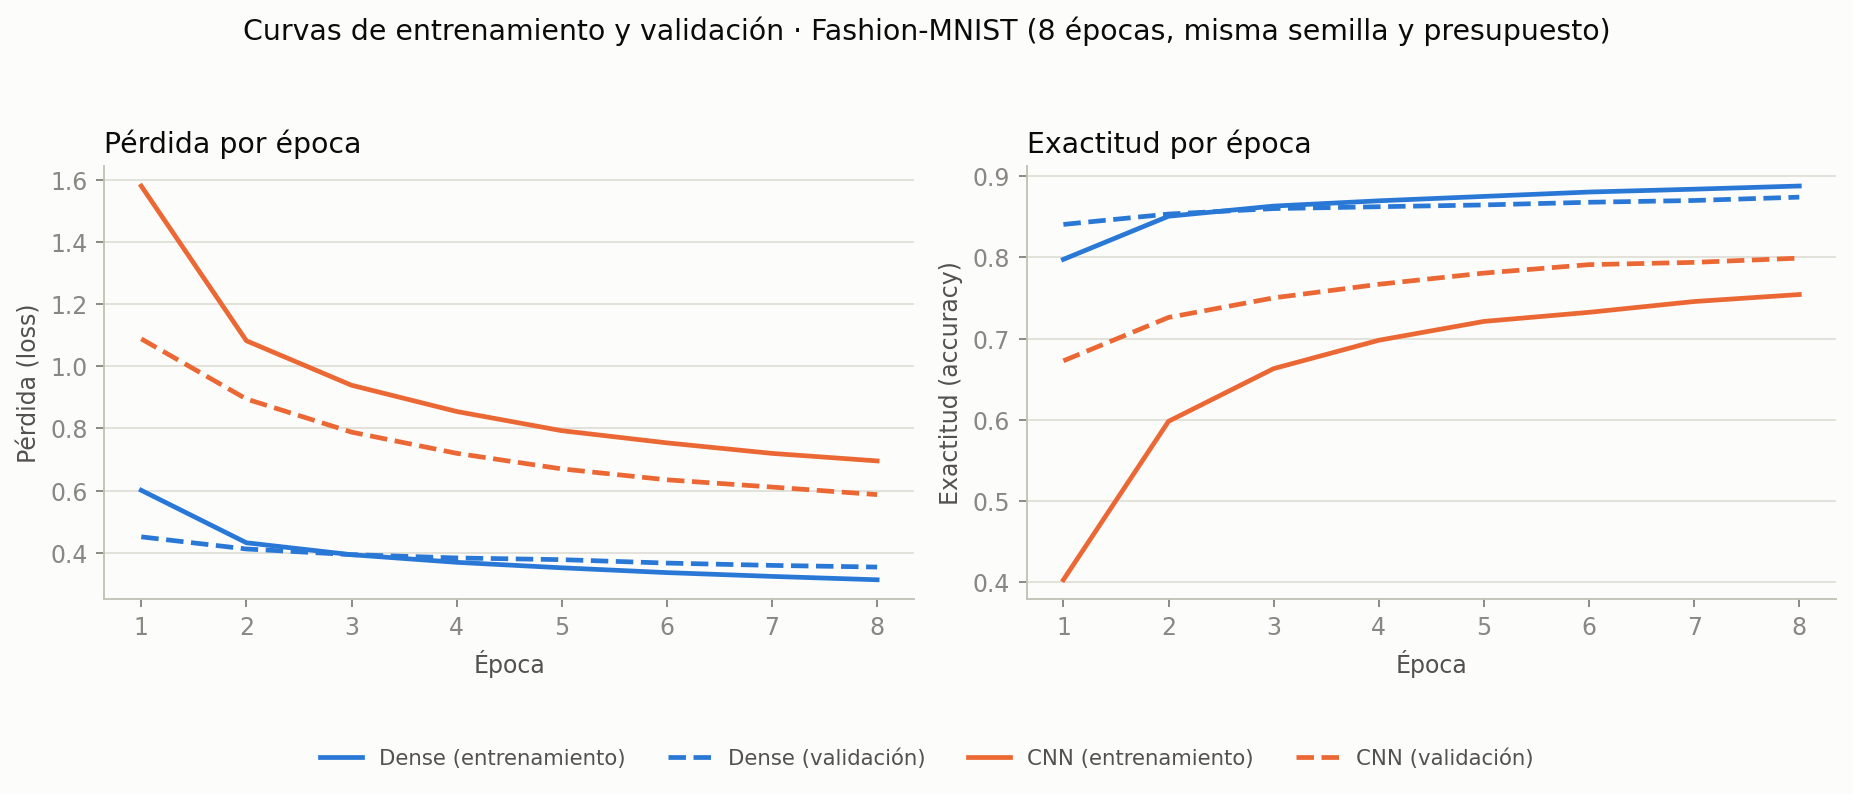

In [5]:
from IPython.display import Image, display

display(Image(filename=str(ROOT / "reports" / "training_curves.png")))

## 6. Evidencia visual: matriz de confusión y errores por clase

La clase "Shirt" (6) es la más débil (F1 ≈ 0.43): se confunde en ambas direcciones con T-shirt/top
y Pullover, como se ve en la matriz de confusión y en los ejemplos de error.

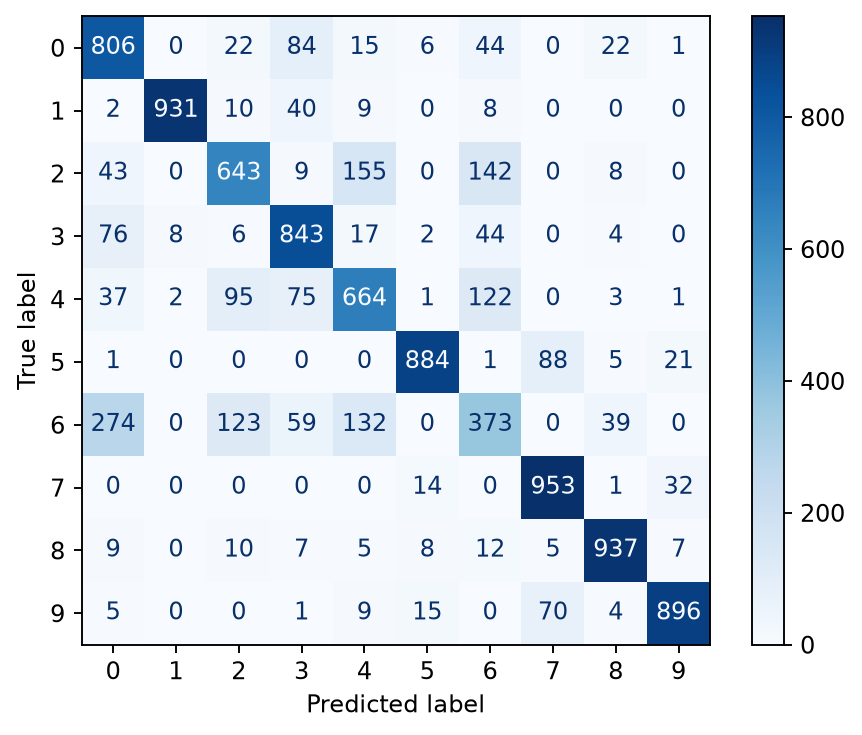

In [6]:
display(Image(filename=str(ROOT / "reports" / "confusion_cnn.png")))

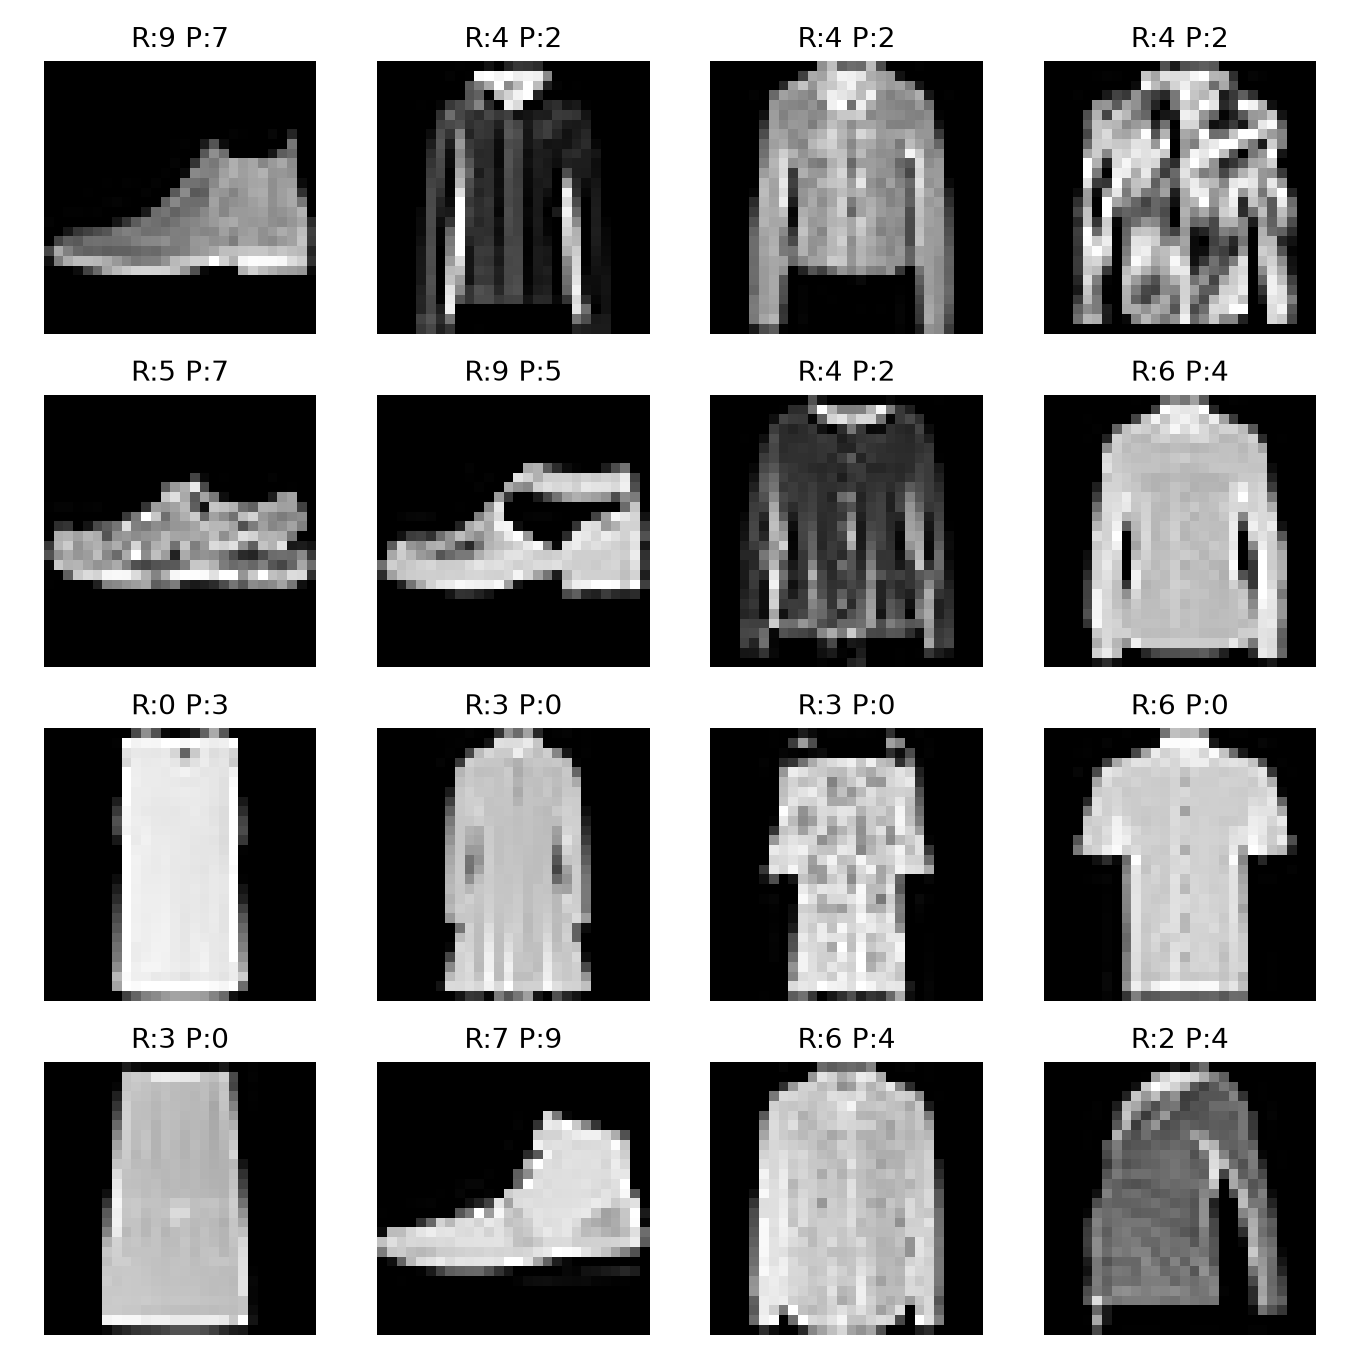

In [7]:
display(Image(filename=str(ROOT / "reports" / "cnn_errors.png")))

## 7. Cierre

El análisis interpretativo completo (resultado principal, costo comparado, decisión Green AI,
limitaciones del benchmark y decisión antes de usar otro dominio) está documentado en la sección
**"Cierre interpretativo"** de `README.md` y en `MODEL_CARD.md` (métricas por clase, comparación de
costo, limitaciones y supervisión).